NSE Session: 200
NIFTY 50 Spot: 22421.95

Selected Expiry: 06-Oct-2026
Days to Expiry: 4

Options available: 278


,strike,type,iv,iv_pct,ltp,volume,oi
172,20200.0,PE,0.3269,32.69,0.70,243.0,126.0
3,20200.0,PE,0.3269,32.69,0.70,243.0,126.0
4,20250.0,PE,0.3262,32.62,0.85,234.0,139.0
173,20250.0,PE,0.3262,32.62,0.85,234.0,139.0
174,20300.0,PE,0.3246,32.46,1.00,1835.0,454.0
5,20300.0,PE,0.3246,32.46,1.00,1835.0,454.0
6,20350.0,PE,0.3207,32.07,1.10,408.0,91.0
175,20350.0,PE,0.3207,32.07,1.10,408.0,91.0
176,20400.0,PE,0.3178,31.78,1.25,1360.0,355.0
7,20400.0,PE,0.3178,31.78,1.25,1360.0,355.0



========== GREEKS ==========


,strike,type,IV,Delta,Vega,Vanna,Volga,LTP,Volume,OI
0,20200.0,PE,32.69,-0.0010,8.0121,-0.0319,230.7937,0.70,243.0,126.0
1,20200.0,PE,32.69,-0.0010,8.0121,-0.0319,230.7937,0.70,243.0,126.0
2,20250.0,PE,32.62,-0.0013,9.7960,-0.0382,270.7871,0.85,234.0,139.0
3,20250.0,PE,32.62,-0.0013,9.7960,-0.0382,270.7871,0.85,234.0,139.0
4,20300.0,PE,32.46,-0.0015,11.6467,-0.0448,311.2026,1.00,1835.0,454.0
...,...,...,...,...,...,...,...,...,...,...
273,24600.0,CE,28.17,0.0009,7.5118,0.0356,259.7994,0.65,62522.0,18748.0
274,24600.0,CE,28.17,0.0009,7.5118,0.0356,259.7994,0.65,62522.0,18748.0
275,24600.0,PE,45.24,-0.9726,148.2613,0.2747,1237.8331,2165.75,34.0,269.0
276,24650.0,CE,28.51,0.0009,6.8267,0.0323,237.9192,0.60,9709.0,1786.0


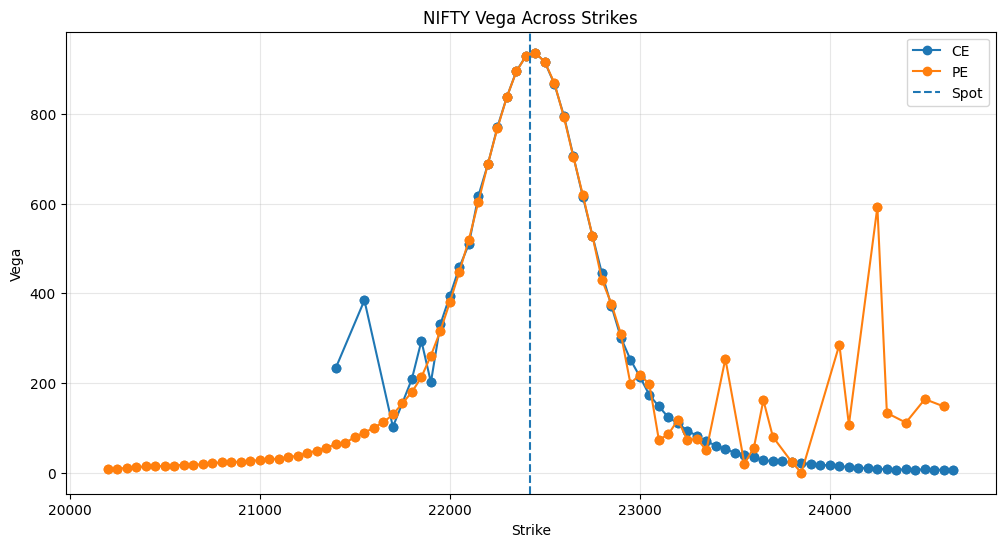

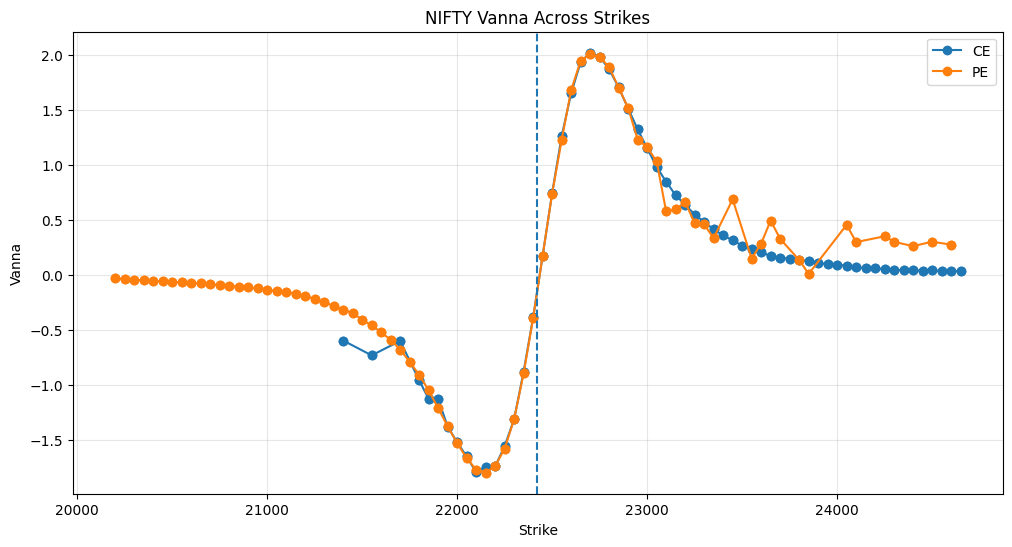

In [ ]:
# ============================================================
# PROJECT 3
# NIFTY VOLATILITY SURFACE RISK
# Vega • Vanna • Volga • IV Shock P&L
# ============================================================

!pip -q install curl_cffi pandas numpy scipy matplotlib

from curl_cffi import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. NSE SESSION
# ============================================================

session = requests.Session(impersonate="chrome")

session.headers.update({
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.nseindia.com/option-chain",
    "User-Agent":
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/128.0.0.0 Safari/537.36"
})

home = session.get(
    "https://www.nseindia.com/option-chain",
    timeout=20
)

print("NSE Session:", home.status_code)

# ============================================================
# 2. NIFTY SPOT
# ============================================================

r = session.get(
    "https://www.nseindia.com/api/allIndices",
    timeout=20
)

if r.status_code != 200:
    raise Exception("NSE index API failed.")

index_data = r.json()

spot = None

for item in index_data.get("data", []):

    if str(item.get("index", "")).upper() == "NIFTY 50":

        spot = float(item["last"])
        break

if spot is None:
    raise Exception("NIFTY 50 spot not found.")

print(f"NIFTY 50 Spot: {spot:.2f}")

# ============================================================
# 3. EXPIRY INFORMATION
# ============================================================

contract_url = (
    "https://www.nseindia.com/"
    "api/option-chain-contract-info"
)

r = session.get(
    contract_url,
    params={"symbol": "NIFTY"},
    timeout=20
)

if r.status_code != 200:
    raise Exception("Expiry API failed.")

contract_data = r.json()

# ============================================================
# 4. FIND EXPIRIES
# ============================================================

def find_expiries(obj):

    result = []

    if isinstance(obj, dict):

        for key, value in obj.items():

            if "expiry" in str(key).lower():

                if isinstance(value, list):

                    for x in value:

                        if isinstance(x, str):
                            result.append(x)

            result.extend(find_expiries(value))

    elif isinstance(obj, list):

        for x in obj:
            result.extend(find_expiries(x))

    return result


expiry_strings = list(
    dict.fromkeys(
        find_expiries(contract_data)
    )
)

# ============================================================
# 5. PARSE DATES
# ============================================================

def parse_expiry(x):

    formats = [
        "%d-%b-%Y",
        "%d-%B-%Y",
        "%d/%b/%Y",
        "%d/%B/%Y",
        "%Y-%m-%d",
        "%Y/%m/%d"
    ]

    for fmt in formats:

        try:
            return datetime.strptime(x, fmt)

        except:
            pass

    return None


today = datetime.now()

future_expiries = []

for expiry in expiry_strings:

    dt = parse_expiry(expiry)

    if dt is not None and dt.date() >= today.date():

        future_expiries.append(
            (dt, expiry)
        )

future_expiries = sorted(
    future_expiries,
    key=lambda x: x[0]
)

if len(future_expiries) == 0:

    raise Exception(
        "No future expiries found."
    )

# ============================================================
# 6. SELECT NEAREST EXPIRY
# ============================================================

expiry_dt, expiry = future_expiries[0]

days_to_expiry = max(
    (expiry_dt.date() - today.date()).days,
    1
)

T = days_to_expiry / 365.0

print("\nSelected Expiry:", expiry)
print("Days to Expiry:", days_to_expiry)

# ============================================================
# 7. DOWNLOAD OPTION CHAIN
# ============================================================

url = (
    "https://www.nseindia.com/"
    "api/option-chain-v3"
)

params = {
    "type": "Indices",
    "symbol": "NIFTY",
    "expiry": expiry
}

r = session.get(
    url,
    params=params,
    timeout=20
)

if r.status_code != 200:

    raise Exception(
        f"Option-chain API failed: {r.status_code}"
    )

chain = r.json()

# ============================================================
# 8. EXTRACT OPTIONS
# ============================================================

def extract_records(obj):

    output = []

    if isinstance(obj, dict):

        strike = None

        for key in [
            "strikePrice",
            "strike_price",
            "strike"
        ]:

            if key in obj:

                try:
                    strike = float(obj[key])

                except:
                    pass

        ce = obj.get("CE")
        pe = obj.get("PE")

        if strike is not None:

            if isinstance(ce, dict):

                output.append({
                    "strike": strike,
                    "type": "CE",
                    "option": ce
                })

            if isinstance(pe, dict):

                output.append({
                    "strike": strike,
                    "type": "PE",
                    "option": pe
                })

        for value in obj.values():

            output.extend(
                extract_records(value)
            )

    elif isinstance(obj, list):

        for item in obj:

            output.extend(
                extract_records(item)
            )

    return output


records = extract_records(chain)

if len(records) == 0:

    raise Exception(
        "No option records found."
    )

# ============================================================
# 9. CREATE DATAFRAME
# ============================================================

rows = []

for row in records:

    option = row["option"]

    iv = option.get(
        "impliedVolatility"
    )

    ltp = option.get(
        "lastPrice"
    )

    volume = option.get(
        "totalTradedVolume"
    )

    oi = option.get(
        "openInterest"
    )

    try:
        iv = float(iv)

    except:
        continue

    try:
        ltp = float(ltp)

    except:
        ltp = np.nan

    try:
        volume = float(volume)

    except:
        volume = 0

    try:
        oi = float(oi)

    except:
        oi = 0

    if iv <= 0 or iv > 100:
        continue

    rows.append({

        "strike": row["strike"],

        "type": row["type"],

        "iv": iv / 100.0,

        "iv_pct": iv,

        "ltp": ltp,

        "volume": volume,

        "oi": oi
    })


df = pd.DataFrame(rows)

# Keep liquid ATM region

df = df[
    (df["strike"] >= spot * 0.90) &
    (df["strike"] <= spot * 1.10)
].copy()

df = df.sort_values(
    "strike"
)

print(
    "\nOptions available:",
    len(df)
)

display(
    df.head(20).round(4)
)

# ============================================================
# 10. BLACK-SCHOLES d1 / d2
# ============================================================

rfr = 0.06

def d1_calc(S, K, T, r, sigma):

    return (
        np.log(S / K)
        +
        (r + 0.5 * sigma**2) * T
    ) / (
        sigma * np.sqrt(T)
    )


def d2_calc(d1, sigma, T):

    return d1 - sigma * np.sqrt(T)


# ============================================================
# 11. GREEKS
# ============================================================

def calculate_greeks(
    S,
    K,
    T,
    r,
    sigma,
    option_type
):

    d1 = d1_calc(
        S,
        K,
        T,
        r,
        sigma
    )

    d2 = d2_calc(
        d1,
        sigma,
        T
    )

    pdf = norm.pdf(d1)

    if option_type == "CE":

        delta = norm.cdf(d1)

    else:

        delta = norm.cdf(d1) - 1

    # Vega per 1.00 volatility change

    vega = (
        S
        * pdf
        * np.sqrt(T)
    )

    # Vanna
    #
    # dDelta / dSigma

    vanna = (
        -pdf
        * d2
        / sigma
    )

    # Volga / Vomma
    #
    # dVega / dSigma

    volga = (
        vega
        * d1
        * d2
        / sigma
    )

    return (
        delta,
        vega,
        vanna,
        volga
    )


# ============================================================
# 12. CALCULATE RISK
# ============================================================

risk_rows = []

for _, row in df.iterrows():

    delta, vega, vanna, volga = calculate_greeks(

        spot,

        row["strike"],

        T,

        rfr,

        row["iv"],

        row["type"]
    )

    risk_rows.append({

        "strike":
            row["strike"],

        "type":
            row["type"],

        "IV":
            row["iv_pct"],

        "Delta":
            delta,

        "Vega":
            vega,

        "Vanna":
            vanna,

        "Volga":
            volga,

        "LTP":
            row["ltp"],

        "Volume":
            row["volume"],

        "OI":
            row["oi"]
    })


risk_df = pd.DataFrame(
    risk_rows
)

print(
    "\n========== GREEKS =========="
)

display(
    risk_df.round(4)
)

# ============================================================
# 13. VEGA PROFILE
# ============================================================

plt.figure(
    figsize=(12, 6)
)

for option_type in ["CE", "PE"]:

    temp = risk_df[
        risk_df["type"] == option_type
    ]

    plt.plot(
        temp["strike"],
        temp["Vega"],
        marker="o",
        label=option_type
    )

plt.axvline(
    spot,
    linestyle="--",
    label="Spot"
)

plt.xlabel(
    "Strike"
)

plt.ylabel(
    "Vega"
)

plt.title(
    "NIFTY Vega Across Strikes"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# 14. VANNA PROFILE
# ============================================================

plt.figure(
    figsize=(12, 6)
)

for option_type in ["CE", "PE"]:

    temp = risk_df[
        risk_df["type"] == option_type
    ]

    plt.plot(
        temp["strike"],
        temp["Vanna"],
        marker="o",
        label=option_type
    )

plt.axvline(
    spot,
    linestyle="--"
)

plt.xlabel(
    "Strike"
)

plt.ylabel(
    "Vanna"
)

plt.title(
    "NIFTY Vanna Across Strikes"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# 15. VOLGA PROFILE
# ============================================================

plt.figure(
    figsize=(12, 6)
)

for option_type in ["CE", "PE"]:

    temp = risk_df[
        risk_df["type"] == option_type
    ]

    plt.plot(
        temp["strike"],
        temp["Volga"],
        marker="o",
        label=option_type
    )

plt.axvline(
    spot,
    linestyle="--"
)

plt.xlabel(
    "Strike"
)

plt.ylabel(
    "Volga / Vomma"
)

plt.title(
    "NIFTY Volga Across Strikes"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# 16. IV SHOCK ANALYSIS
# ============================================================

shocks = [
    -0.05,
    -0.02,
     0.00,
     0.02,
     0.05
]

shock_results = []

for shock in shocks:

    shock_total = 0

    for _, row in risk_df.iterrows():

        base_iv = row["IV"] / 100

        shocked_iv = max(
            base_iv + shock,
            0.0001
        )

        _, vega, vanna, volga = calculate_greeks(

            spot,

            row["strike"],

            T,

            rfr,

            base_iv,

            row["type"]
        )

        # Taylor approximation:
        #
        # dP ≈ Vega*dσ
        #      + 0.5*Volga*dσ²

        pnl = (
            vega * shock
            +
            0.5 * volga * shock**2
        )

        shock_total += pnl

    shock_results.append({

        "IV_Shock":
            shock * 100,

        "Portfolio_PnL":
            shock_total
    })


shock_df = pd.DataFrame(
    shock_results
)

print(
    "\n========== IV SHOCK ANALYSIS =========="
)

display(
    shock_df.round(4)
)

# ============================================================
# 17. IV SHOCK P&L
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    shock_df["IV_Shock"],
    shock_df["Portfolio_PnL"],
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "IV Shock (%)"
)

plt.ylabel(
    "Approximate P&L"
)

plt.title(
    "NIFTY Portfolio P&L Under IV Shocks"
)

plt.grid(
    alpha=0.3
)

plt.show()

# ============================================================
# 18. VEGA-VOLGA DECOMPOSITION
# ============================================================

base_vega = 0
base_volga = 0

for _, row in risk_df.iterrows():

    base_vega += row["Vega"]

    base_volga += row["Volga"]


print(
    "\n========== VOLATILITY RISK =========="
)

print(
    "Aggregate Vega:",
    round(base_vega, 4)
)

print(
    "Aggregate Volga:",
    round(base_volga, 4)
)

# ============================================================
# 19. ATM OPTION RISK
# ============================================================

atm_idx = (
    np.abs(
        risk_df["strike"] - spot
    )
).idxmin()

atm_option = risk_df.loc[
    atm_idx
]

print(
    "\n========== ATM RISK =========="
)

print(
    "ATM Strike:",
    atm_option["strike"]
)

print(
    "ATM IV:",
    round(atm_option["IV"], 2),
    "%"
)

print(
    "Delta:",
    round(atm_option["Delta"], 4)
)

print(
    "Vega:",
    round(atm_option["Vega"], 4)
)

print(
    "Vanna:",
    round(atm_option["Vanna"], 4)
)

print(
    "Volga:",
    round(atm_option["Volga"], 4)
)

# ============================================================
# 20. RISK HEATMAP DATA
# ============================================================

pivot_vega = risk_df.pivot_table(
    index="strike",
    columns="type",
    values="Vega"
)

pivot_vanna = risk_df.pivot_table(
    index="strike",
    columns="type",
    values="Vanna"
)

pivot_volga = risk_df.pivot_table(
    index="strike",
    columns="type",
    values="Volga"
)

# ============================================================
# 21. EXPORT
# ============================================================

risk_df.to_csv(
    "NIFTY_Volatility_Surface_Risk.csv",
    index=False
)

shock_df.to_csv(
    "NIFTY_IV_Shock_PnL.csv",
    index=False
)

pivot_vega.to_csv(
    "NIFTY_Vega_Profile.csv"
)

pivot_vanna.to_csv(
    "NIFTY_Vanna_Profile.csv"
)

pivot_volga.to_csv(
    "NIFTY_Volga_Profile.csv"
)

# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print(
    "\n=============================================="
)

print(
    "PROJECT 3 COMPLETE"
)

print(
    "=============================================="
)

print(
    "✓ NIFTY Option Chain"
)

print(
    "✓ Implied Volatility"
)

print(
    "✓ Black-Scholes Delta"
)

print(
    "✓ Vega"
)

print(
    "✓ Vanna"
)

print(
    "✓ Volga / Vomma"
)

print(
    "✓ Vega Surface/Profile"
)

print(
    "✓ Vanna Profile"
)

print(
    "✓ Volga Profile"
)

print(
    "✓ IV Shock Analysis"
)

print(
    "✓ Volatility P&L"
)

print(
    "✓ Risk CSV Files"
)

print(
    "=============================================="
)